In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


project_root = Path.cwd().resolve().parents[1]
sys.path.append(str(project_root / "CODE" / "PaperCode"))

from factor_simulation import RiskFactorSimulator

In [7]:


# Example inputs
num_risk_factors = 3
initial_spot_values = [100.0, 60.0, 140.0]
drift_array = [0.03, 0.03, 0.03]
volatility_array = [0.10, 0.25, 0.40]
correl_matrix = [
    [1.0, 0.80, 0.10],
    [0.80, 1.0, -0.5],
    [0.10, -0.5, 1.0],
]
# Irregular time grid is allowed
time_steps = np.linspace(0,10,50)
num_sims = 1000

simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps
)

paths = simulator.simulate_paths(num_sims=num_sims)


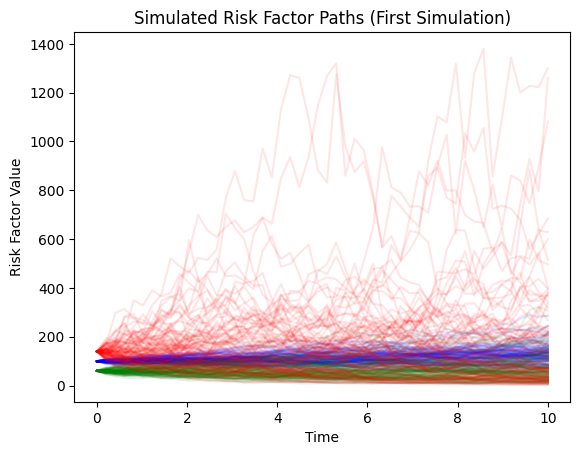

In [8]:
plt.plot(time_steps, paths[:100, :, 0].numpy().T, color='blue', alpha=0.1)
plt.plot(time_steps, paths[:100, :, 1].numpy().T, color='green', alpha=0.1)
plt.plot(time_steps, paths[:100, :, 2].numpy().T, color='red', alpha=0.1)
plt.title("Simulated Risk Factor Paths (First Simulation)")
plt.xlabel("Time")
plt.ylabel("Risk Factor Value")
plt.show()

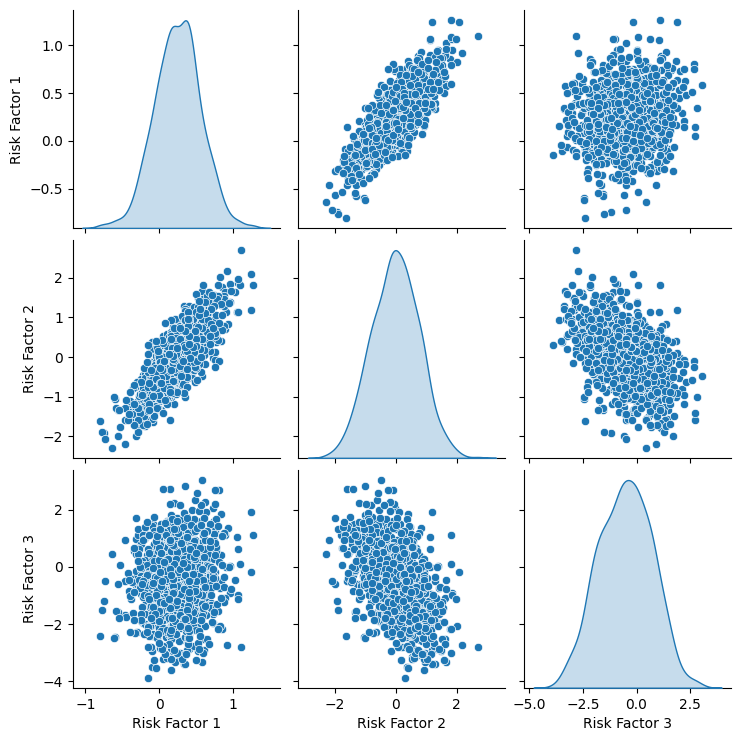

In [9]:
sns.pairplot(
    pd.DataFrame(np.log(paths[:,-1,:].numpy()/paths[:,0,:].numpy()), columns=[f"Risk Factor {i+1}" for i in range(num_risk_factors)]),
    diag_kind="kde")

In [ ]:
time_steps = [0.0, 0.5, 1.0, 2.5, 5.0, 7.5, 10.0, 15.0, 30.0]

corr_matrix = [[1.0, 0.80, 0.10],
               [0.80, 1.0, -0.5],
                [0.10, -0.5, 1.0]]

simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps)

paths = simulator.simulate_paths(num_sims=30000)

for i in range(len(time_steps)-1):

    returns = np.log(paths[:,i+1,:].numpy()/paths[:,i,:].numpy())

    print("Volatilities at time step ", time_steps[i], ":", np.std(returns, axis=0)/np.sqrt(time_steps[i+1]-time_steps[i]))
    print("Correl matrix at time step ", time_steps[i], ":")
    print(np.corrcoef(returns.T))
    



Volatilities at time step  0.0 : [0.09973517 0.2495146  0.39992198]
Correl matrix at time step  0.0 :
[[ 1.          0.79921101  0.10068162]
 [ 0.79921101  1.         -0.50062897]
 [ 0.10068162 -0.50062897  1.        ]]
Volatilities at time step  0.5 : [0.10012323 0.25100021 0.39969442]
Correl matrix at time step  0.5 :
[[ 1.          0.80280862  0.09297755]
 [ 0.80280862  1.         -0.5019605 ]
 [ 0.09297755 -0.5019605   1.        ]]
Volatilities at time step  1.0 : [0.10049807 0.25110421 0.40100766]
Correl matrix at time step  1.0 :
[[ 1.          0.80187576  0.09802416]
 [ 0.80187576  1.         -0.499166  ]
 [ 0.09802416 -0.499166    1.        ]]
Volatilities at time step  2.5 : [0.0999858  0.25003708 0.40075845]
Correl matrix at time step  2.5 :
[[ 1.          0.79997235  0.09873337]
 [ 0.79997235  1.         -0.50117458]
 [ 0.09873337 -0.50117458  1.        ]]
Volatilities at time step  5.0 : [0.1000167  0.24980793 0.3987342 ]
Correl matrix at time step  5.0 :
[[ 1.          0.8

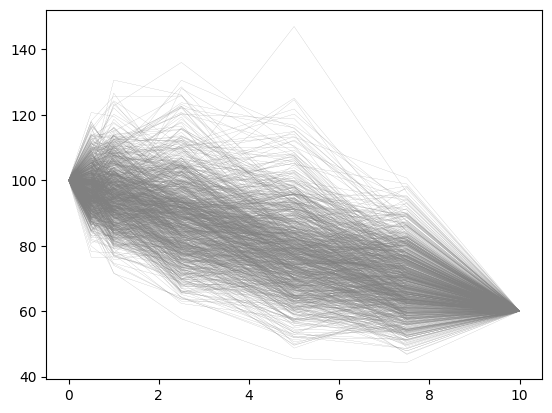

In [26]:
spot_t = [60,140,100]

time_index = 6

brown_paths = simulator.simulate_paths_with_bridge(num_sims = 1000,
        pivot_step_idx = 6,
        spot_at_pivot= spot_t)


plt.plot(time_steps[0:time_index+1], brown_paths[:,:,0].T.detach(), linewidth = 0.1, color = 'grey');



In [ ]:
plt.plot(paths_bridge[0:100,:,0].cpu().detach().numpy().T)

NameError: name 'paths_bridge' is not defined

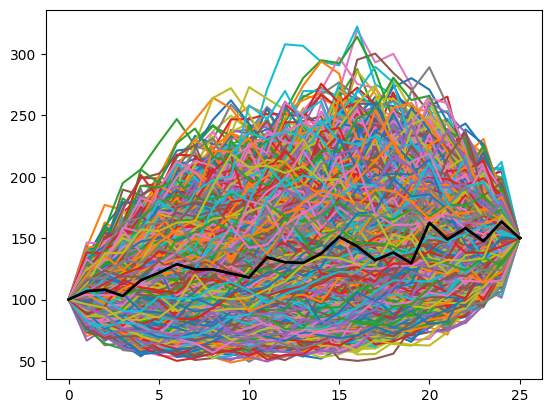

In [21]:
plt.plot(paths_bridge[:,:,0].cpu().detach().numpy().T);

plt.plot(paths_bridge[50,:,0].cpu().detach().numpy().T, color='black', linewidth=2);


In [22]:

log_returns_bridge = torch.log(paths_bridge[:, 1:, :] / paths_bridge[:, :-1, :])

#
# Volatility per factor from log returns: sqrt(E[r^2 / dt])
vol_bridge = torch.sqrt(
    (log_returns_bridge ** 2 / dt[0:pivot_step_idx].unsqueeze(0).unsqueeze(-1)).mean(dim=(0, 1))
)

# Correlation of standardized return shocks
std_shocks_bridge = log_returns_bridge / torch.sqrt(dt[0:pivot_step_idx].unsqueeze(0).unsqueeze(-1))
X_bridge = std_shocks_bridge.reshape(-1, simulator.num_risk_factors)
corr_bridge = torch.corrcoef(X_bridge.T)

print("Volatility estimates from bridge log returns:")
print(vol_bridge.detach().cpu().numpy())

print("\nCorrelation matrix from bridge log returns:")
print(corr_bridge.detach().cpu().numpy())

Volatility estimates from bridge log returns:
[0.19937617 0.24489068 0.17625571]

Correlation matrix from bridge log returns:
[[1.         0.2994083  0.09839933]
 [0.2994083  1.         0.25017303]
 [0.09839933 0.25017303 1.        ]]


In [ ]:
paths_bridge.shape

torch.Size([20000, 26, 3])

: 